**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

**Load Dataset**

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Income Prediction Dataset/adult.csv")

print(df.head())
print(df.info())

   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                  ?      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  White  Female             0   
4     Prof-specialty      Own-child  White  Female             0   

   capital.loss  hours.per.week native.country income  
0          4356              40  United-States  <=50K  
1          4356              18  United-States

**Handle Missing Values**

In [3]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Drop missing values
df.dropna(inplace=True)
print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


**Encode Categorical Columns**

In [4]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

**Data Visualization**

Histogram (All Features)

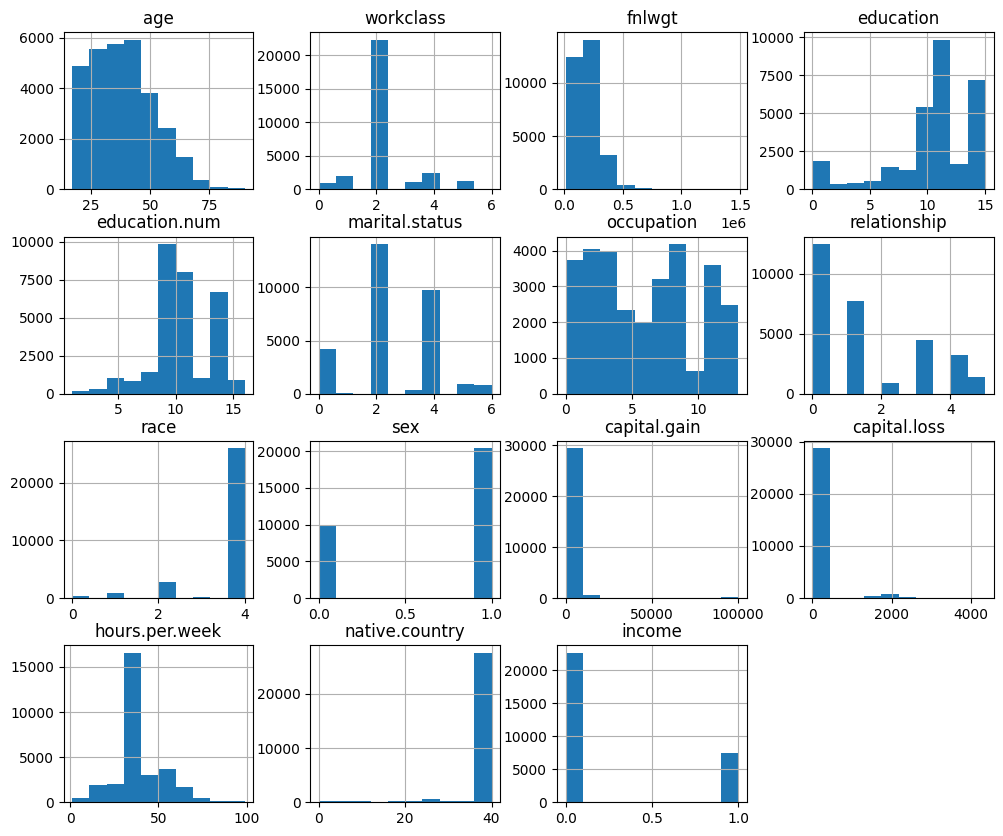

In [5]:
df.hist(figsize=(12,10))
plt.show()

**Target Distribution**

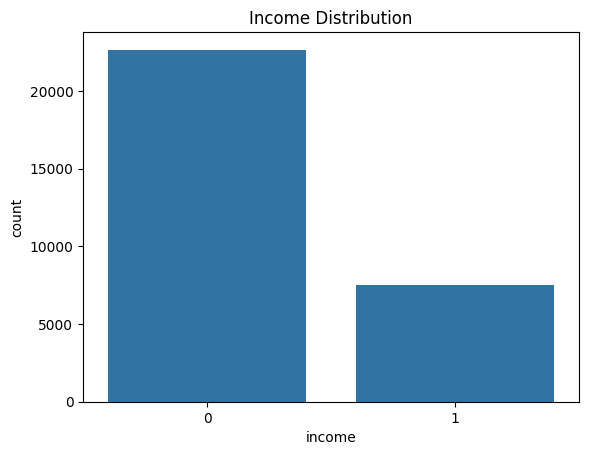

In [6]:
sns.countplot(x=df['income'])
plt.title("Income Distribution")
plt.show()

**Define Features & Target**

In [7]:
X = df.drop('income', axis=1)
y = df['income']

**Train Test Split**

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Feature Scaling**

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Train Models**

Logistic Regression

In [10]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Accuracy: 0.8178352395159953


**KNN**

In [11]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.8224763799104923


**Decision Tree**

In [12]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8015912481352561


**Naive Bayes**

In [13]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.792971987402619


**SVC**

In [14]:
svc = SVC(probability=True)
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)

print("SVC Accuracy:", accuracy_score(y_test, y_pred_svc))

SVC Accuracy: 0.8362340460798939


**ACCURACY VISUALIZATION**

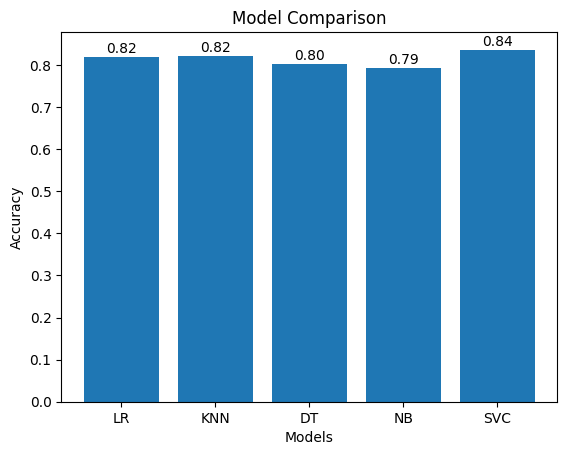

In [15]:
models = ['LR', 'KNN', 'DT', 'NB', 'SVC']
scores = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_svc)
]

plt.bar(models, scores)

# Add values on top of bars
for i, v in enumerate(scores):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

**CONFUSION MATRIX FOR Prediction**

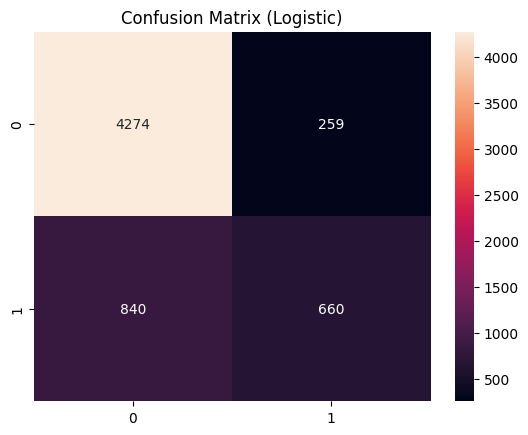

In [16]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Logistic)")
plt.show()

**ROC Curve for Prediction**

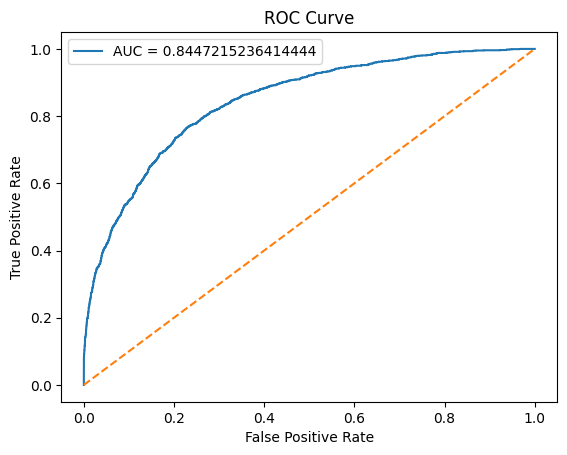

In [17]:
y_prob = lr.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**CONFUSION MATRIX FOR ALL MODELS**

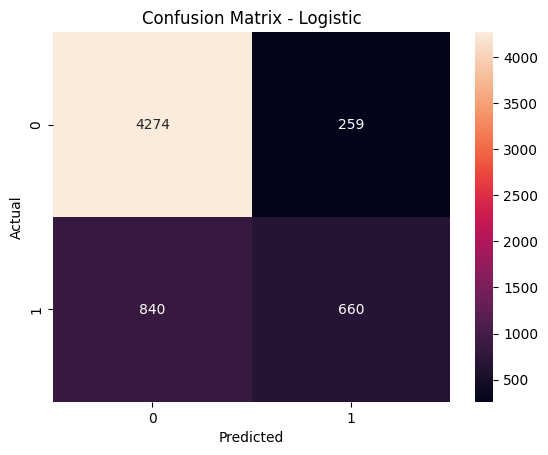

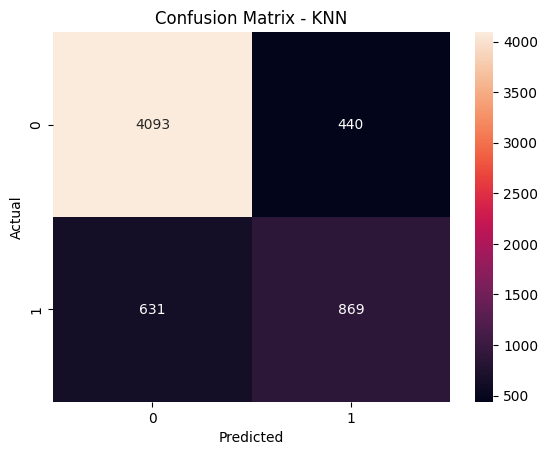

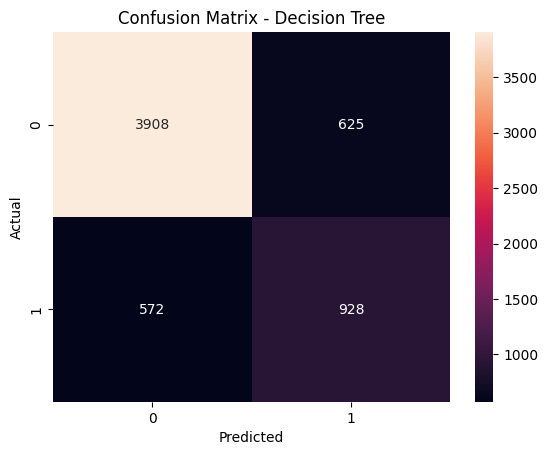

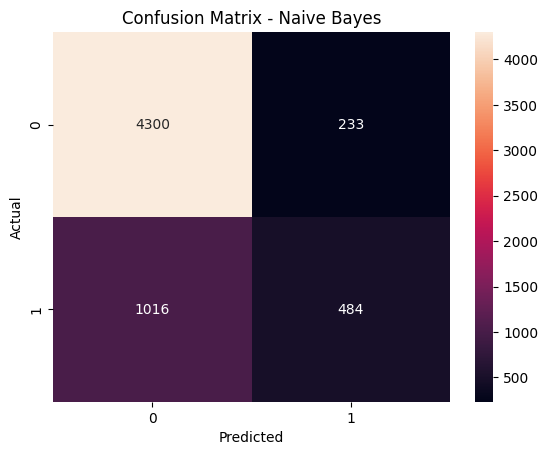

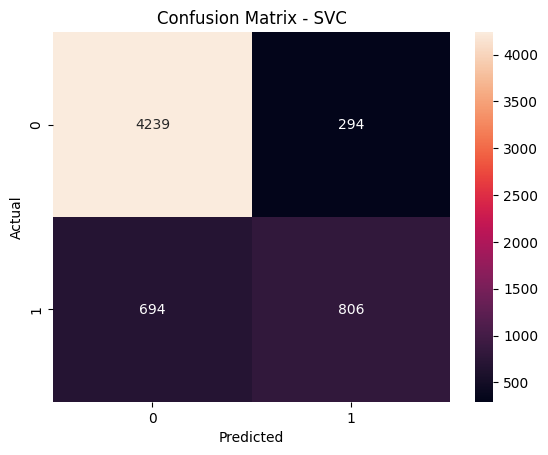

In [18]:
models_preds = {
    "Logistic": y_pred_lr,
    "KNN": y_pred_knn,
    "Decision Tree": y_pred_dt,
    "Naive Bayes": y_pred_nb,
    "SVC": y_pred_svc
}

for name, pred in models_preds.items():
    plt.figure()
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

**ROC CURVE FOR ALL ALGORITHMS**

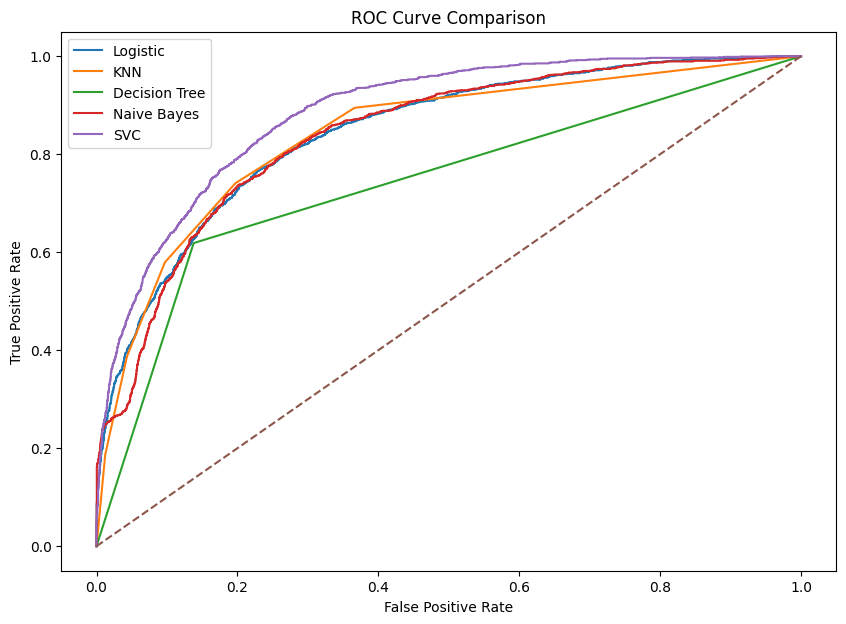

In [19]:
plt.figure(figsize=(10,7))

# Logistic Regression
y_prob_lr = lr.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr, tpr, label="Logistic")

# KNN
y_prob_knn = knn.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_knn)
plt.plot(fpr, tpr, label="KNN")

# Decision Tree
y_prob_dt = dt.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_dt)
plt.plot(fpr, tpr, label="Decision Tree")

# Naive Bayes
y_prob_nb = nb.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_nb)
plt.plot(fpr, tpr, label="Naive Bayes")

# SVC
y_prob_svc = svc.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_svc)
plt.plot(fpr, tpr, label="SVC")

# Random line
plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

CORRELATION MATRIX (AFTER IMPLEMENTATION)

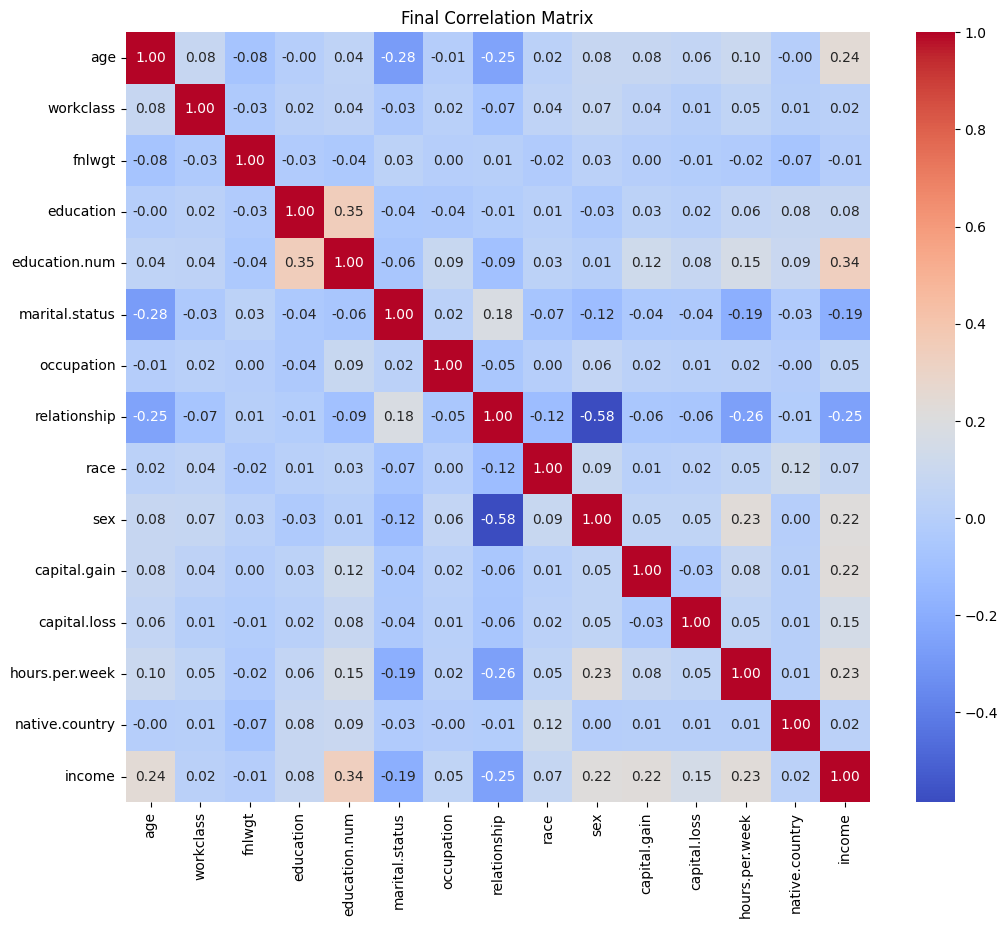

In [20]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Final Correlation Matrix")
plt.show()